# Benchmark 1D 

Example of creation of a multifidelity Neural Network to create the model that connects the input variables to the function itself. After that, it is possible to build a Markov Chain Monte Carlo alogoritm to discover the original input value, considered in general unknown. 

In this case, we are facing a Discontinuous function

In [1]:
import tensorflow.keras.backend as K
from tensorflow.keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from hyperopt.pyll.base import scope
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam,Nadam,Adamax
from time import perf_counter
import tensorflow as tf

import tinyDA as tda
from scipy.stats import multivariate_normal, uniform
import arviz as az
import keras

from module_utils import * 
sys.path.append('../utils')
from Structure import *

from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)

Ray module not found. Multiprocessing features are not available


True

In [2]:
seed = 10
tf.random.set_seed(seed)
np.random.seed(seed)
keras.utils.set_random_seed(seed)

# Creation of the model

In [3]:
#Benchmark1
lowfid = lambda x: (0.5*(6.*x/5.-2.)**2*np.sin(12.*x/5.-4)+10.*(x/5-0.5)-5.)*(x<2.5) + (3+0.5*(6.*x/5.-2)**2*np.sin(12.*x/5.-4)+10*(x/5.-0.5)-5.)*(x>2.5)
highfid = lambda x: (2*lowfid(x)- 20*x/5.+20)*(x/5.<0.5) + (4+2*lowfid(x)- 20*x/5.+20)*(x/5.>0.5)
Nhf = 6
Nlf = 32
N = Nhf + Nlf
xhf = np.linspace(0,5,Nhf)
xlf = np.linspace(0,5,Nlf)
x_test = np.linspace(0,5,1000)
Yhf = highfid(xhf)
Ylf = lowfid(xlf)
NepoLF = 5000
NepoHF = 1200

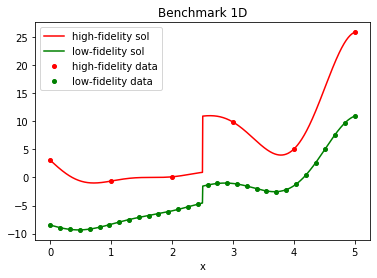

In [4]:
#%% Plot functions
plt.figure()
plt.plot(x_test,highfid(x_test),'r', label = 'high-fidelity sol')
plt.plot(x_test,lowfid(x_test),'g', label = 'low-fidelity sol')
plt.plot(xhf,highfid(xhf),'ro', label = 'high-fidelity data', markersize = 4)
plt.plot(xlf,lowfid(xlf),'go', label = 'low-fidelity data', markersize = 4)
plt.xlabel('x')
plt.legend()
plt.title('Benchmark 1D')
plt.show()

## Low fidelity model

The function training took 22.524876832962036 seconds.


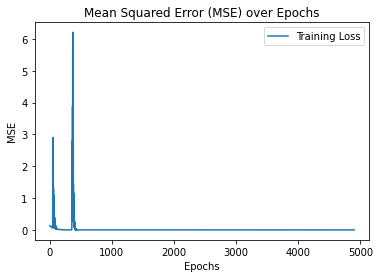

Test MSE: 82.23769850932104
R^2: -0.6790232595573984


In [5]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelLF=NetworkFactory.build_network('LF',params=bestLF_params,data_train=xlf,output_train=Ylf,N=NepoLF,n=Nlf,train=True,do_HPO=False,verbose=False)
yLF=modelLF.prediction(x_test)
(mse_LF,R_LF)=modelLF.performance(x_test,highfid(x_test))

## High fidelity model

The function training took 6.1472344398498535 seconds.


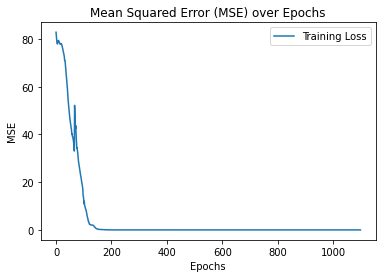

Test MSE: 11.78303544188726
R^2: 0.7594291798806173


In [6]:
bestHF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
modelHF=NetworkFactory.build_network('LF',params=bestHF_params,data_train=xhf,output_train=Yhf,N=NepoHF,n=Nhf,train=True,do_HPO=False,verbose=False)
yHF=modelHF.prediction(x_test)
(mse_HF,R_HF)=modelHF.performance(x_test,highfid(x_test))

## 2 Step model

The function training took 22.42778205871582 seconds.


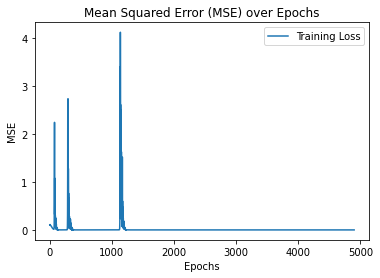

The function training took 6.534057140350342 seconds.


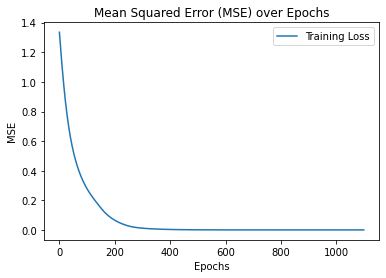

Test MSE: 6.327758306546256
R^2: 0.8708079923182128


In [7]:
bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'}
best_params = {'kernel_init': 'uniform', 'l2weight': 0.00010018625799978436, 'lr': 0.07093837044166487, 'nodes': 74.0, 'opt': 'Adamax'}
N=[NepoLF,NepoHF]
n=[Nlf,Nhf]
names=['LF','HF']

params=[bestLF_params,best_params]
final_model=NetworkFactory.build_network("2step",names,params=params,data_train=[xlf,xhf],output_train=[Ylf,Yhf],N=N,n=n,do_HPO=False,verbose=False)
y_test=final_model.prediction(x_test)

input_HF = np.concatenate(
                    (x_test.reshape(-1,1),  final_model.model_list[0].prediction(x_test).reshape(-1,1)),axis=1
                ) 
(mse_MF,R_MF)=final_model.model_list[1].performance(input_HF,highfid(x_test))

## Plots

Text(0.5, 1.0, 'High fidelity model - 2-step')

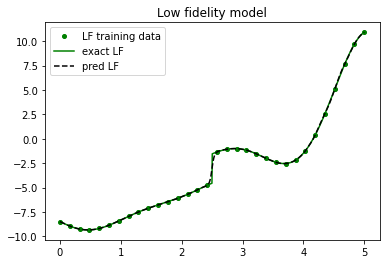

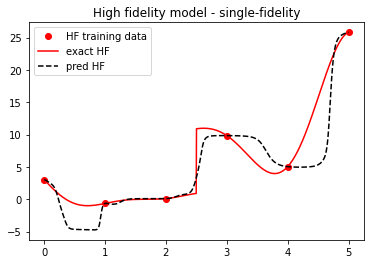

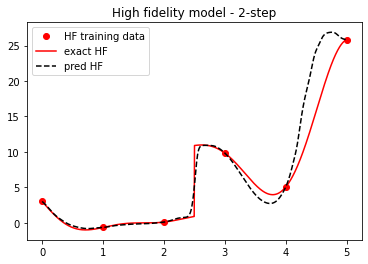

In [8]:
#LF
plt.figure()
plt.plot(xlf,Ylf,'go', label = 'LF training data', markersize = 4)
plt.plot(x_test,lowfid(x_test),'g', label = 'exact LF') 
plt.plot(x_test,yLF,'k--', label = 'pred LF')
plt.legend()
plt.title('Low fidelity model')

#HF single-fidelity
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,yHF,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - single-fidelity')

#2-step MF
plt.figure()
plt.plot(xhf,Yhf,'ro', label = 'HF training data')
plt.plot(x_test,highfid(x_test),'-r', label = 'exact HF')
plt.plot(x_test,y_test,'--k', label = 'pred HF')
plt.legend()
plt.title('High fidelity model - 2-step')

In [ ]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.4,0.45])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
cov_prior = np.ones(dim)*5*0.2 
sigma=0.2
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =8000#10000
burnin = 3000
n_chains=4
values=np.array([0.05,0.1,0.2,0.5,1.])

In [ ]:
    estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

# MCMC using tinyDA

In [15]:
dim=4
#real_x = np.random.rand(dim)*5
real_x=np.array([0.2,0.3,0.4,0.45])*5
# Set parameters for the MCMC

mean_prior = np.ones(dim)*2.5
#cov_prior = np.ones(dim)*5*mult#*0.1 
#sigma=0.1*mult
rwmh_cov = np.eye(len(real_x)) # !
rmwh_scaling = 0.1
rwmh_adaptive = False
iterations =8000#10000
burnin = 3000
n_chains=1
values=np.array([0.05,0.1,0.2,0.5,1.])

# Multifidelity

real values are [1.   1.5  2.   2.25]
Sampling chain 1/1


Running chain, α = 0.05: 100%|██████████| 8000/8000 [20:38<00:00,  6.46it/s]
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)


estimated values are [3.74  1.684 1.646 3.74 ]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.740  0.018   3.706    3.776      0.001    0.001     225.0     193.0   
x1  1.684  0.209   1.341    2.079      0.036    0.026      33.0      43.0   
x2  1.646  0.268   1.117    2.045      0.090    0.066      11.0      44.0   
x3  3.740  0.023   3.696    3.781      0.002    0.001     181.0     217.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  


c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\utils.py:187: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  numba_fn = numba.jit(**self.kwargs)(self.function)


Autocorrelation...


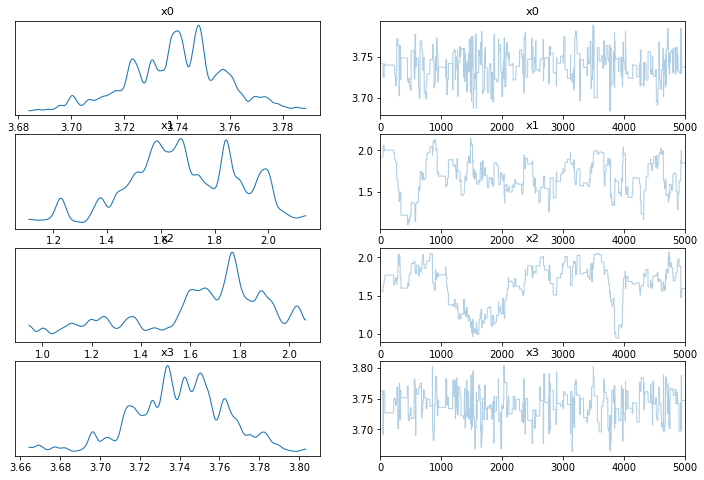

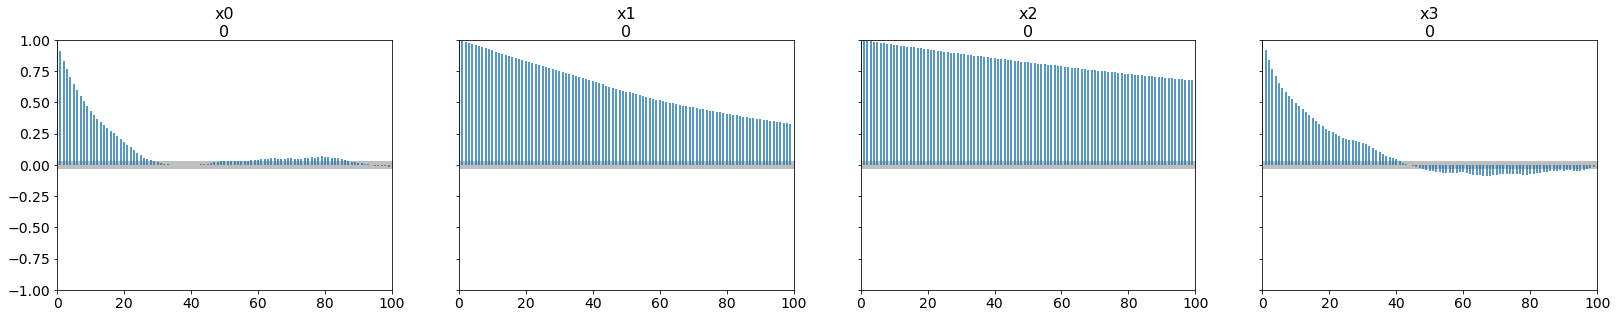

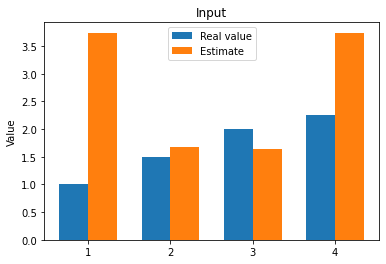

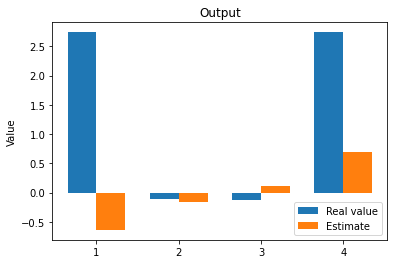

The function inverse took 1244.2338757514954 seconds.
real values are [1.   1.5  2.   2.25]
Sampling chain 1/1


Running chain, α = 0.04: 100%|██████████| 8000/8000 [20:31<00:00,  6.49it/s]  
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)


estimated values are [3.741 3.742 3.739 2.261]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.741  0.023   3.701    3.783      0.002    0.001     115.0     111.0   
x1  3.742  0.025   3.705    3.787      0.002    0.002     109.0     182.0   
x2  3.739  0.023   3.694    3.775      0.002    0.002      92.0      89.0   
x3  2.261  0.089   2.113    2.405      0.014    0.010      41.0      24.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
Autocorrelation...


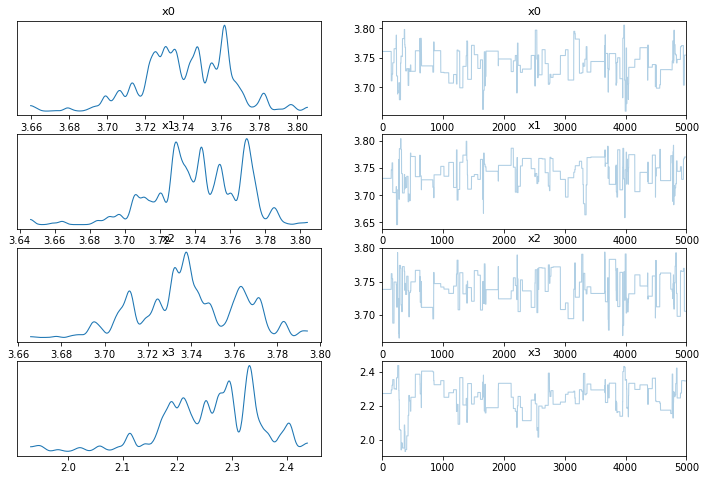

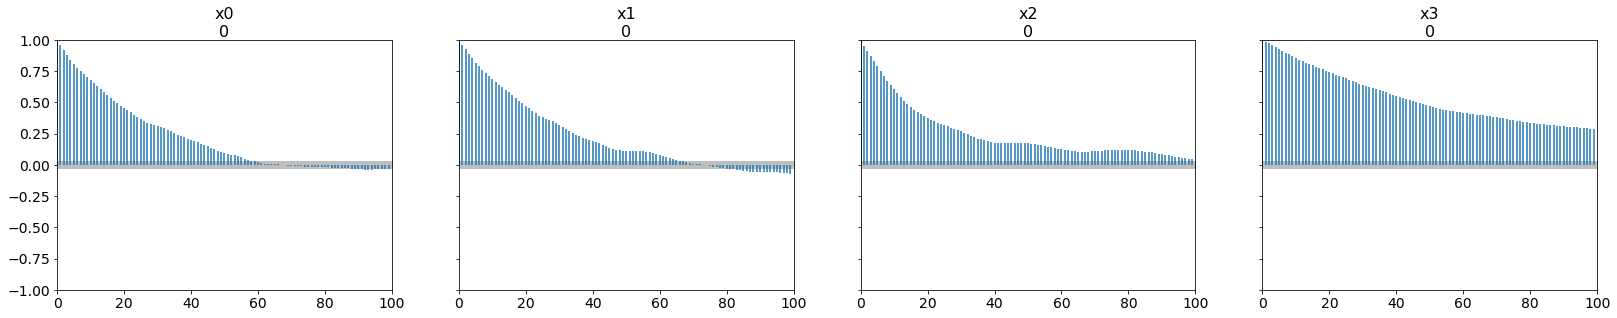

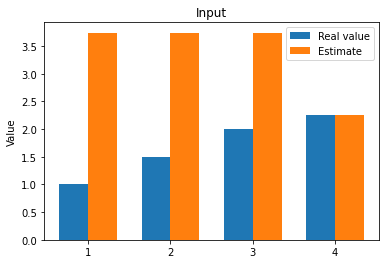

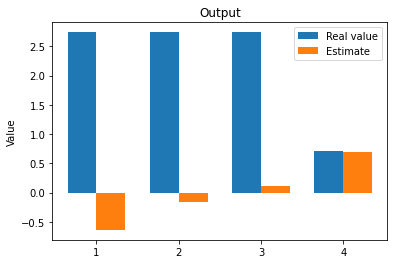

The function inverse took 1234.9666848182678 seconds.
real values are [1.   1.5  2.   2.25]
Sampling chain 1/1


Running chain, α = 0.42: 100%|██████████| 8000/8000 [21:52<00:00,  6.10it/s]   
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)


estimated values are [3.741 1.517 1.874 2.064]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  3.741  0.033   3.678    3.800      0.001    0.001     945.0     954.0   
x1  1.517  0.558   0.337    2.275      0.174    0.127      15.0      39.0   
x2  1.874  0.293   1.401    2.418      0.043    0.031      45.0      81.0   
x3  2.064  0.268   1.547    2.425      0.040    0.028      56.0      89.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
Autocorrelation...


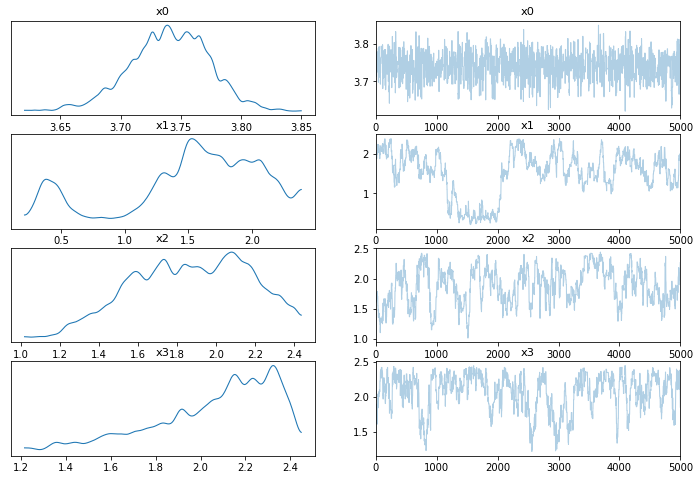

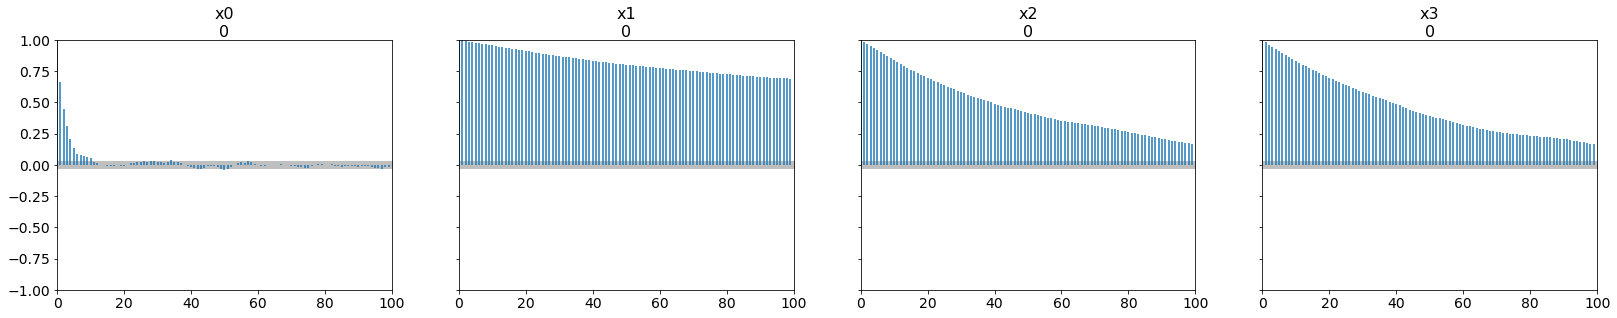

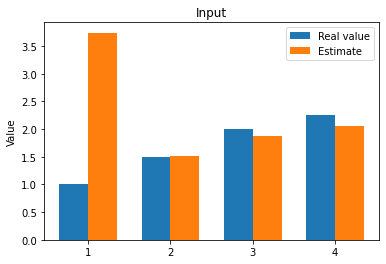

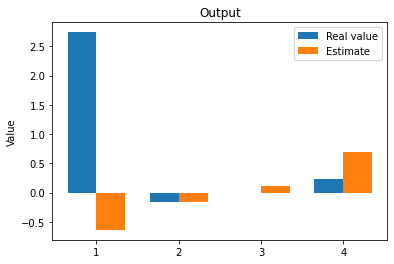

The function inverse took 1316.80956864357 seconds.
real values are [1.   1.5  2.   2.25]
Sampling chain 1/1


Running chain, α = 0.78: 100%|██████████| 8000/8000 [21:44<00:00,  6.13it/s]  
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)
arviz - WARNING - Shape validation failed: input_shape: (1, 5001), minimum_shape: (chains=2, draws=4)


estimated values are [ 1.254 26.817  1.967  1.541]
      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0   1.254  0.646   0.273    2.312      0.217    0.161      13.0     217.0   
x1  26.817  0.594  25.700   27.813      0.098    0.070      36.0     101.0   
x2   1.967  0.366   1.292    2.451      0.049    0.034      66.0     230.0   
x3   1.541  0.453   0.685    2.341      0.066    0.047      50.0     119.0   

    r_hat  
x0    NaN  
x1    NaN  
x2    NaN  
x3    NaN  
Autocorrelation...


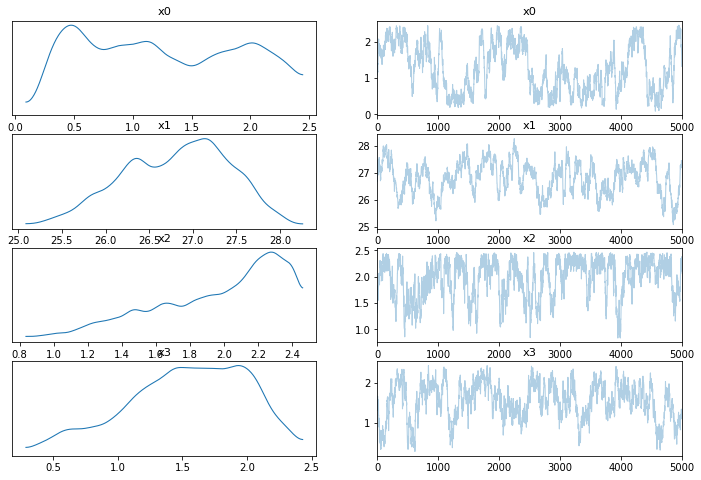

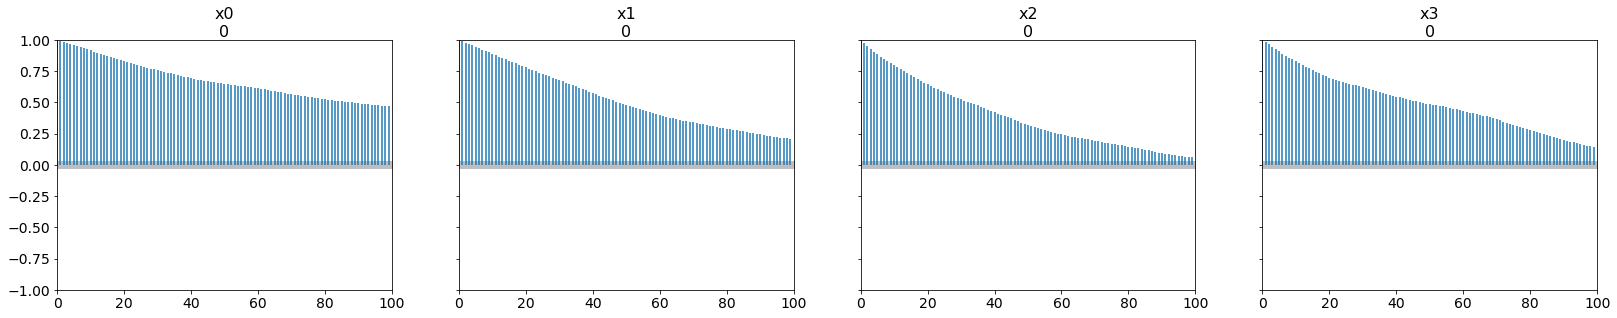

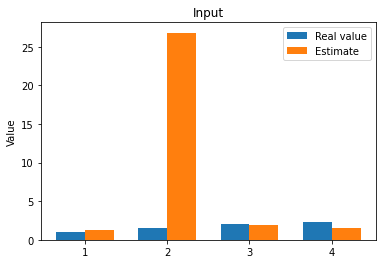

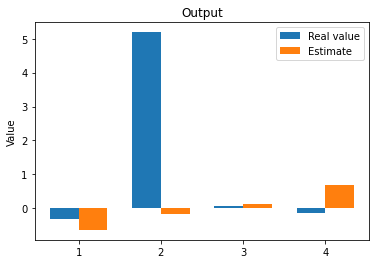

The function inverse took 1311.605634212494 seconds.
real values are [1.   1.5  2.   2.25]
Sampling chain 1/1


Running chain, α = 0.57:  94%|█████████▍| 7526/8000 [21:42<01:16,  6.19it/s]  

: 

In [16]:
for mult in values:
    cov_prior = np.ones(dim)*5*mult#*0.1 
    sigma=mult
    estimate_MF=final_model.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)

### Low Fidelity

real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.75:   0%|          | 2/8000 [00:00<09:50, 13.55it/s]

Running chain, α = 0.11: 100%|██████████| 8000/8000 [10:34<00:00, 12.61it/s]


Sampling chain 2/2


Running chain, α = 0.31: 100%|██████████| 8000/8000 [11:47<00:00, 11.31it/s]   
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [2.915 1.353 3.527 4.209]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  2.915  0.194   2.569    3.234      0.022    0.016      76.0     153.0   
x1  1.353  1.509  -0.187    3.023      1.065    0.901       3.0      99.0   
x2  3.527  0.655   2.703    4.241      0.459    0.389       3.0     100.0   
x3  4.209  0.036   4.150    4.279      0.002    0.001     462.0     505.0   

    r_hat  
x0   1.04  
x1   1.84  
x2   1.83  
x3   1.00  
Autocorrelation...


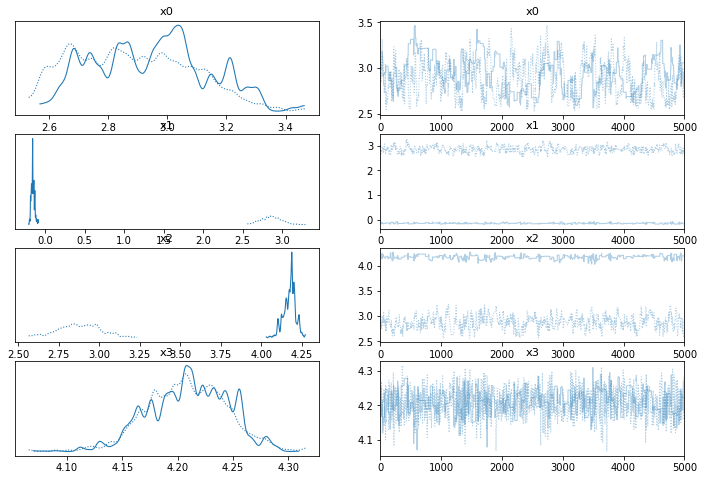

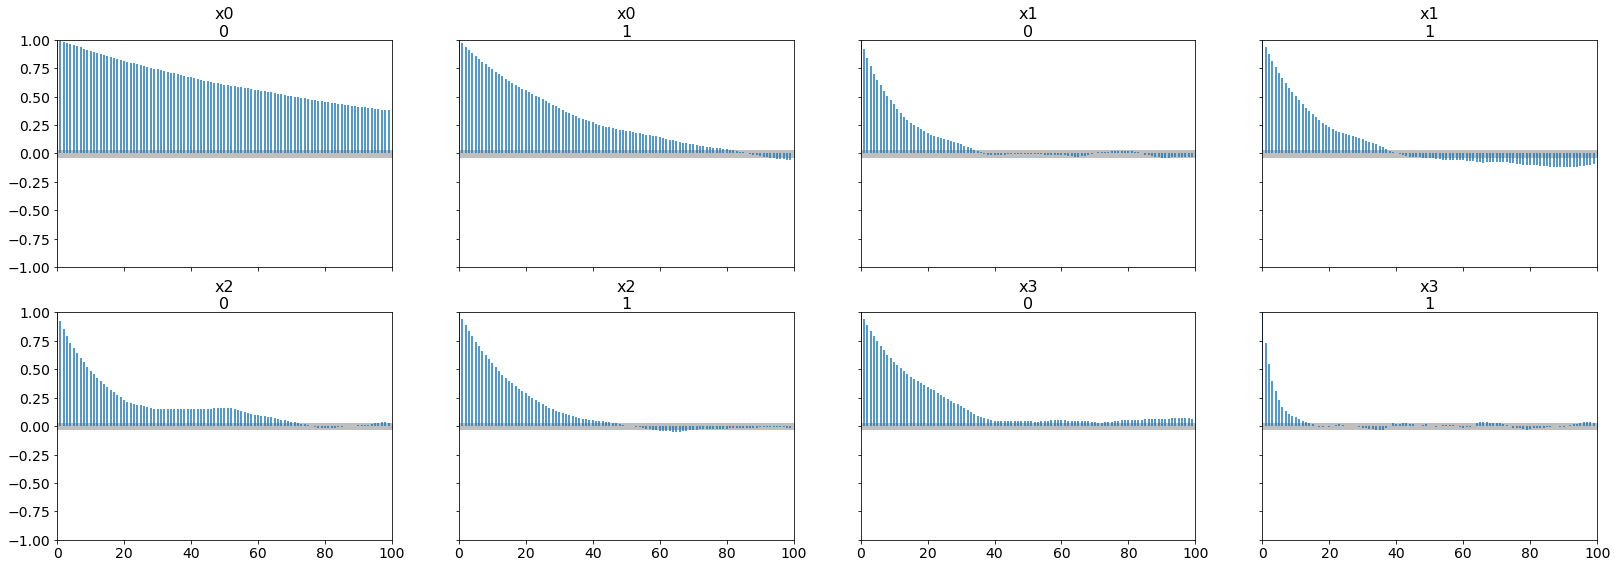

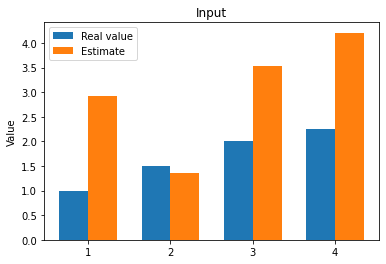

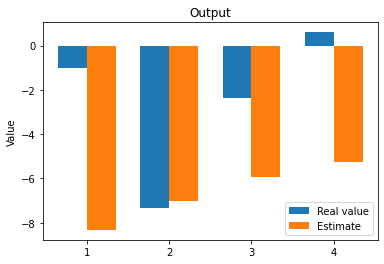

The function inverse took 1346.9989845752716 seconds.


In [ ]:
estimate_LF=modelLF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)


real values are [1.   1.5  2.   2.25]
Sampling chain 1/2


Running chain, α = 0.08: 100%|██████████| 8000/8000 [10:21<00:00, 12.87it/s]


Sampling chain 2/2


Running chain, α = 0.33:   0%|          | 8/8000 [00:00<10:05, 13.20it/s]C:\Users\Giacomo\AppData\Roaming\Python\Python310\site-packages\tinyDA\proposal.py:238: RuntimeWarning: overflow encountered in exp
  return np.exp(proposal_link.posterior - previous_link.posterior)
Running chain, α = 0.39: 100%|██████████| 8000/8000 [11:02<00:00, 12.08it/s] 
c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\arviz\data\inference_data.py:146: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


estimated values are [1.211 2.996 2.954 2.186]
     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x0  1.211  0.245   0.940    1.740      0.043    0.031      55.0      28.0   
x1  2.996  1.217   1.350    4.362      0.845    0.719       3.0      71.0   
x2  2.954  1.252   1.360    4.378      0.876    0.744       3.0      47.0   
x3  2.186  2.013   0.142    4.414      1.421    1.203       3.0      22.0   

    r_hat  
x0   1.04  
x1   1.85  
x2   1.93  
x3   1.88  
Autocorrelation...


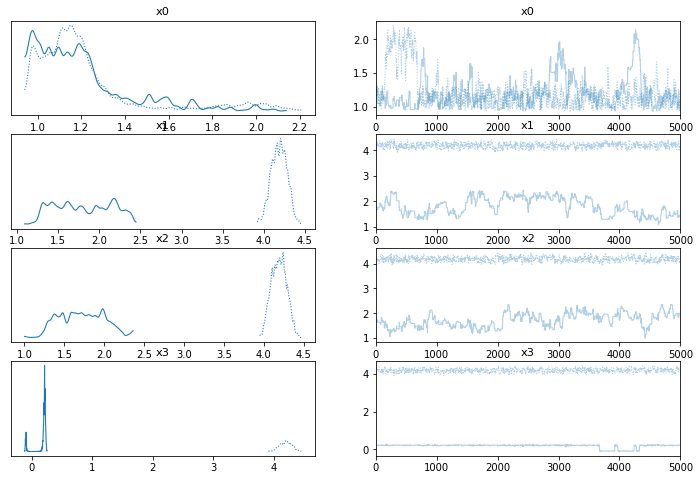

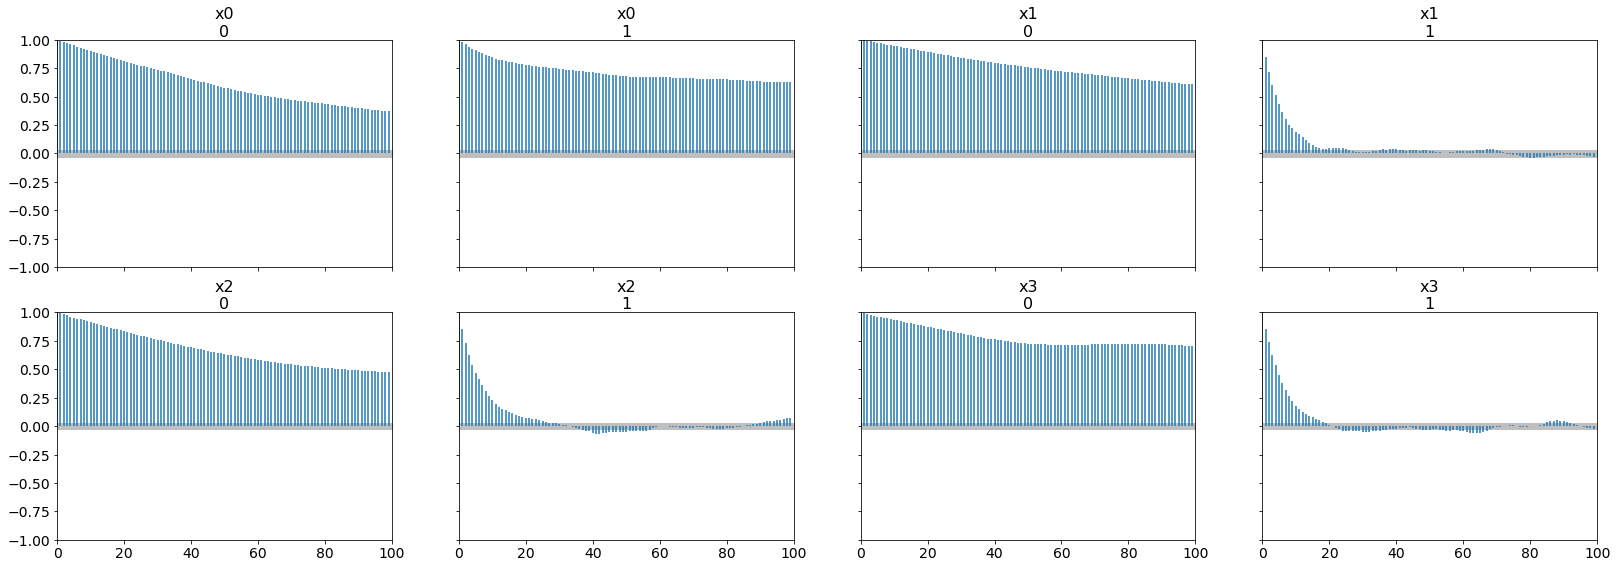

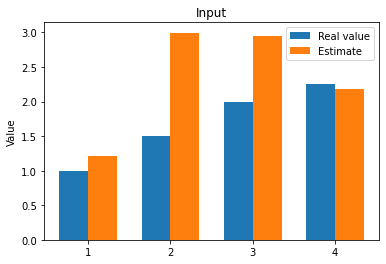

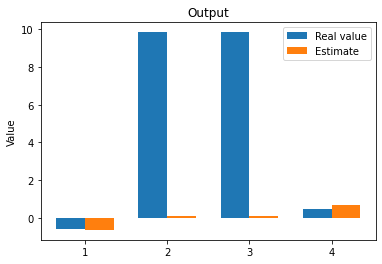

The function inverse took 1289.2964973449707 seconds.


In [ ]:
estimate_HF=modelHF.inverse(mean_prior, cov_prior=cov_prior, cov_noise=sigma, cov_likelihood=sigma*np.eye(real_x.shape[0]), y_obs=highfid(real_x), x_real=real_x, number_chains=n_chains, N=iterations, burn_in=burnin, diagnostic=True,rwmh_cov=rwmh_cov,rmwh_scaling=rmwh_scaling,rwmh_adaptive=rwmh_adaptive)
